In [2]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
import sys
sys.path.append("..") 
from processing import  load_UCI_dataset, print_metrics, plot_regression_results, evaluate_minirocket_vitaldb, train_mlp, select_top_pearson_features

In [4]:
X_train, y_train, X_val, y_val, X_test, y_test = load_UCI_dataset(
    WINDOW_SIZE=1000,
    STEP_SIZE=500
)

BASE_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_50%overlap/vitaldb_checkpoints"

Total recordings: 12000
Train recordings: 9600
Validation recordings: 1200
Test recordings: 1200


100%|██████████| 9600/9600 [02:08<00:00, 74.91it/s] 


Skipped recordings: 103


100%|██████████| 1200/1200 [00:15<00:00, 76.26it/s]


Skipped recordings: 8


100%|██████████| 1200/1200 [00:15<00:00, 75.94it/s]


Skipped recordings: 9


In [5]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (517037, 1, 1000)
y_train: (517037, 2)
X_val: (65284, 1, 1000)
y_val: (65284, 2)
X_test: (65554, 1, 1000)
y_test: (65554, 2)


In [6]:
from sktime.transformations.panel.rocket import MiniRocket

rocket = MiniRocket(num_kernels=5000, random_state=42)

rocket.fit(X_train)

MiniRocket(num_kernels=5000, random_state=42)

In [7]:
def transform_to_disk(rocket, X, path, bs=2000):
    d = rocket.transform(X[:2]).shape[1]
    out = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(X), d))
    for i in tqdm(range(0, len(X), bs)):
        out[i:i+bs] = rocket.transform(X[i:i+bs]).to_numpy(dtype=np.float32)
    out.flush()
    return out

transform_to_disk(rocket, X_train, "X_train_minirocket.npy")
transform_to_disk(rocket, X_val,   "X_val_minirocket.npy")
transform_to_disk(rocket, X_test,  "X_test_minirocket.npy")
del X_train, X_val, X_test; import gc; gc.collect()   # raw windows no longer needed

100%|██████████| 33/33 [00:45<00:00,  1.37s/it]


1773

In [8]:
X_train_rocket = np.load("X_train_minirocket.npy", mmap_mode="r")
X_val_rocket   = np.load("X_val_minirocket.npy",   mmap_mode="r")
X_test_rocket  = np.load("X_test_minirocket.npy",  mmap_mode="r")

In [9]:
y_train_sbp = y_train[:, 0]
y_train_dbp = y_train[:, 1]

y_val_sbp = y_val[:, 0]
y_val_dbp = y_val[:, 1]

y_test_sbp = y_test[:, 0]
y_test_dbp = y_test[:, 1]

## RIDGE REGRESSION ##

In [10]:
class RidgeModel:
    def __init__(s, mu, sd, W, ym, col): s.mu, s.sd, s.W, s.ym, s.col = mu, sd, W, ym, col
    def predict(s, X):
        X = np.asarray(X, dtype=np.float32)
        return ((X - s.mu) / s.sd) @ s.W[:, s.col] + s.ym[s.col]

def ridge_stats(X, Y, bs=5000):
    n, d = X.shape
    XtX = np.zeros((d, d)); Xty = np.zeros((d, Y.shape[1]))
    sx = np.zeros(d); sy = np.zeros(Y.shape[1])
    for i in tqdm(range(0, n, bs)):
        xb = np.asarray(X[i:i+bs], dtype=np.float64); yb = Y[i:i+bs].astype(np.float64)
        XtX += xb.T @ xb; Xty += xb.T @ yb; sx += xb.sum(0); sy += yb.sum(0)
    return XtX, Xty, sx, sy, n

def solve_ridge(stats, alpha):
    XtX, Xty, sx, sy, n = stats
    mu, ym = sx / n, sy / n
    C = XtX - n * np.outer(mu, mu)
    sd = np.sqrt(np.diag(C) / n); sd[sd == 0] = 1
    C = C / np.outer(sd, sd)
    c = (Xty - n * np.outer(mu, ym)) / sd[:, None]
    W = np.linalg.solve(C + alpha * np.eye(len(mu)), c)
    return mu.astype(np.float32), sd.astype(np.float32), W.astype(np.float32), ym.astype(np.float32)

stats = ridge_stats(X_train_rocket, y_train)

best = {}
for col, name in [(0, "SBP"), (1, "DBP")]:
    scores = {}
    for a in [0.01, 0.1, 1, 10, 100, 1000, 10000]:
        mu, sd, W, ym = solve_ridge(stats, a)
        m = RidgeModel(mu, sd, W, ym, col)
        pred = np.concatenate([m.predict(X_val_rocket[i:i+5000]) for i in range(0, len(X_val_rocket), 5000)])
        scores[a] = np.sqrt(np.mean((pred - y_val[:, col])**2))
    a_best = min(scores, key=scores.get)
    print(name, "best alpha:", a_best, "val RMSE:", scores[a_best])
    best[name] = RidgeModel(*solve_ridge(stats, a_best), col)

grid_ridge_sbp, grid_ridge_dbp = best["SBP"], best["DBP"]

100%|██████████| 104/104 [00:42<00:00,  2.45it/s]


SBP best alpha: 10000 val RMSE: 17.002634
DBP best alpha: 10000 val RMSE: 8.78006


In [11]:
def batch_predict(m, X, bs=5000):
    return np.concatenate([m.predict(X[i:i+bs]) for i in range(0, len(X), bs)])

y_pred_sbp = batch_predict(grid_ridge_sbp, X_test_rocket)
y_pred_dbp = batch_predict(grid_ridge_dbp, X_test_rocket)

In [12]:
print("MiniRocket + Ridge — SBP")
print("------------------------")
print_metrics(y_test_sbp, y_pred_sbp)

print("\nMiniRocket + Ridge — DBP")
print("------------------------")
print_metrics(y_test_dbp, y_pred_dbp)

MiniRocket + Ridge — SBP
------------------------
RMSE: 17.3928
MSE : 302.5092
R²  : 0.4258
MAE : 13.2491

MiniRocket + Ridge — DBP
------------------------
RMSE: 8.9423
MSE : 79.9653
R²  : 0.3581
MAE : 6.5341


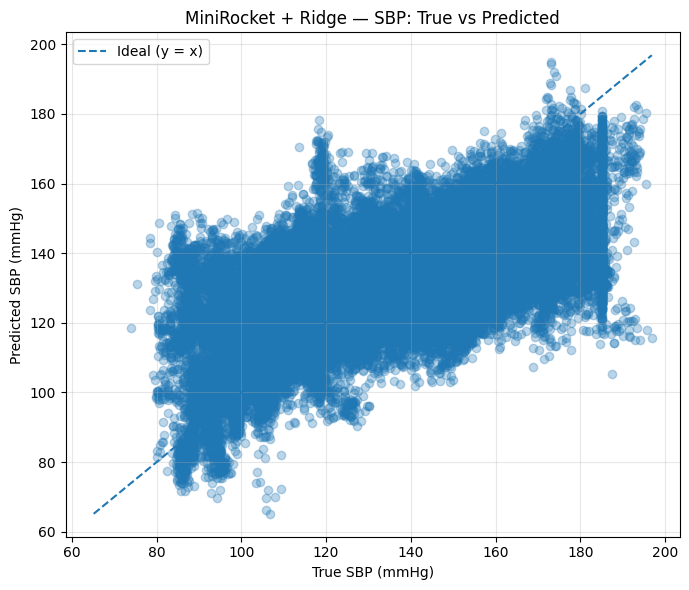

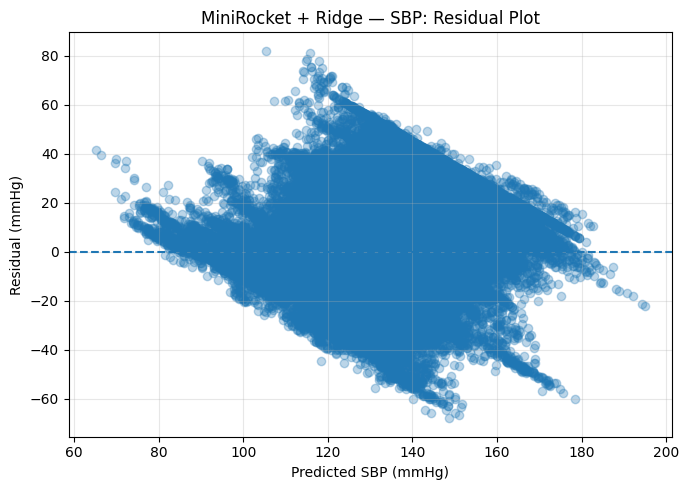

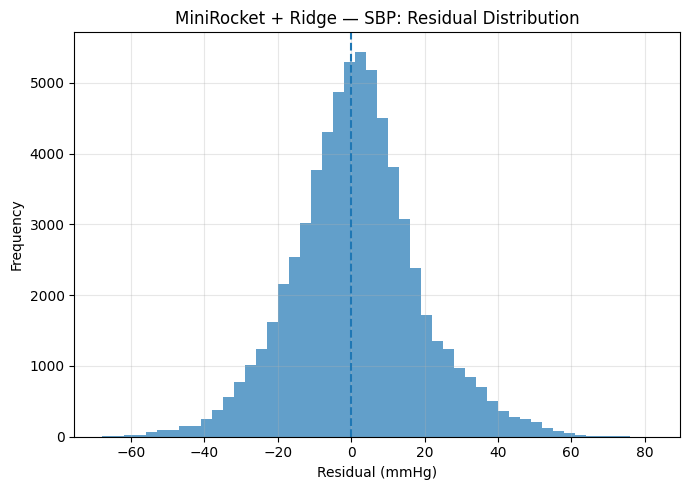

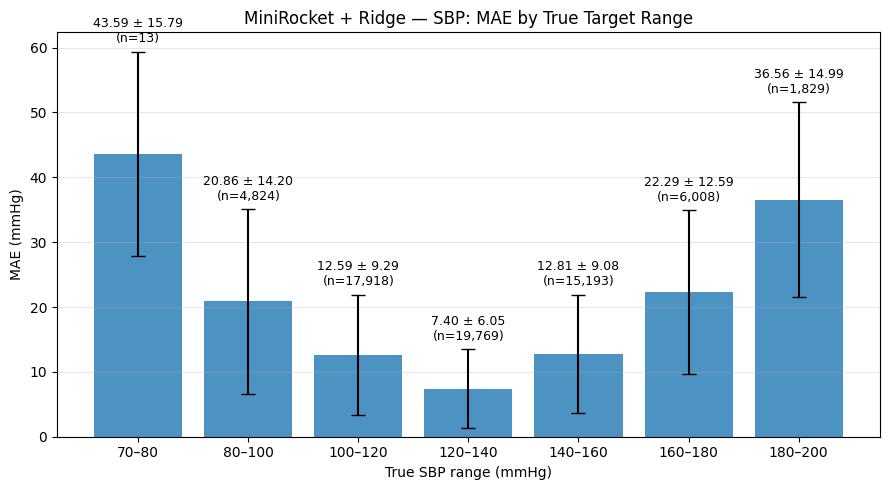

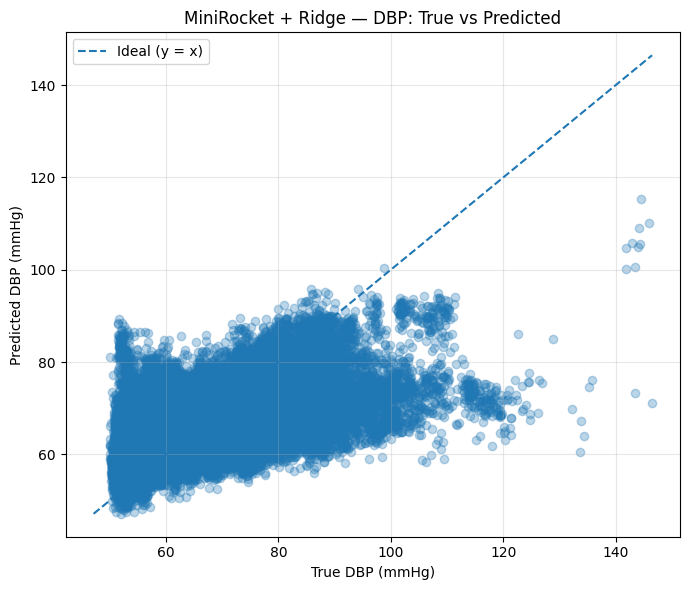

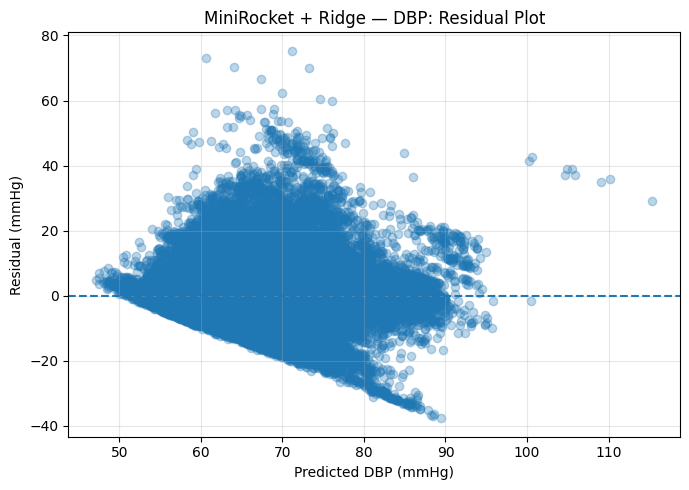

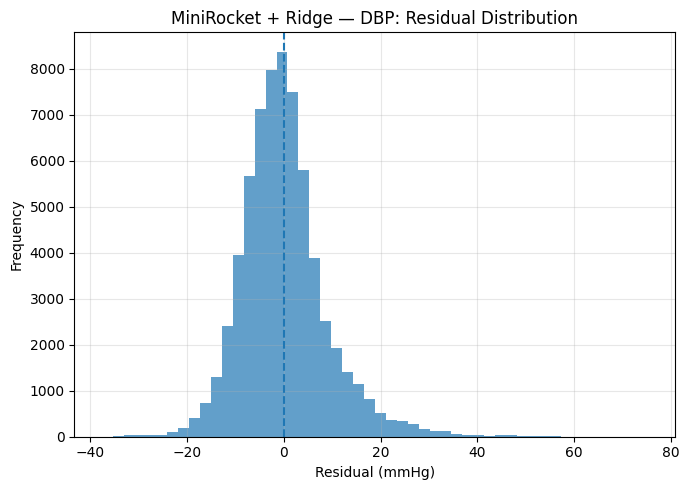

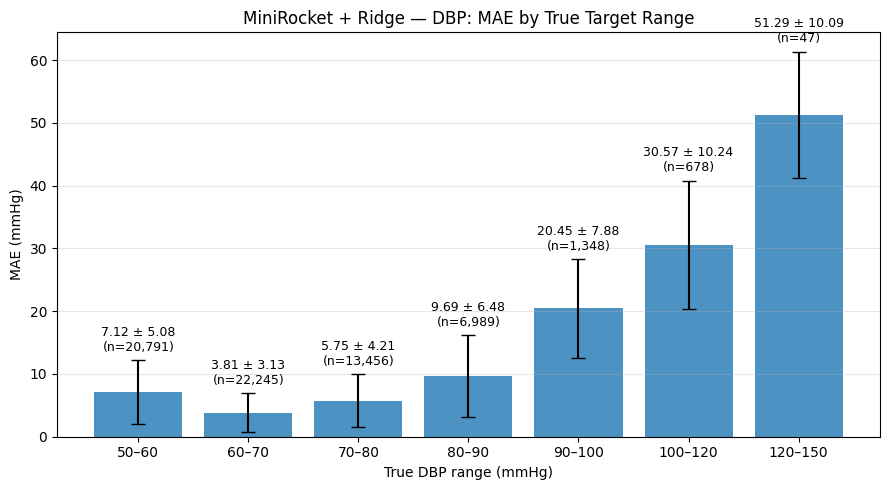

In [13]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + Ridge",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + Ridge",
    "DBP"
)

Number of VitalDB cases: 1962


MiniROCKET VitalDB prediction: 100%|██████████| 1962/1962 [1:08:16<00:00,  2.09s/case]




MiniROCKET + Ridge
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 24.3922
MSE : 594.9812
R²  : -0.3948
MAE : 18.7232

DBP
------------------------------
RMSE: 13.8445
MSE : 191.6689
R²  : -0.1849
MAE : 10.7366


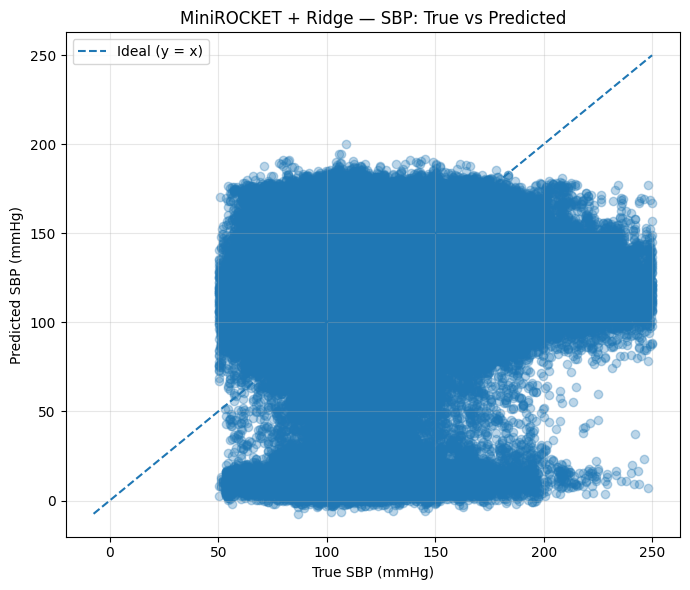

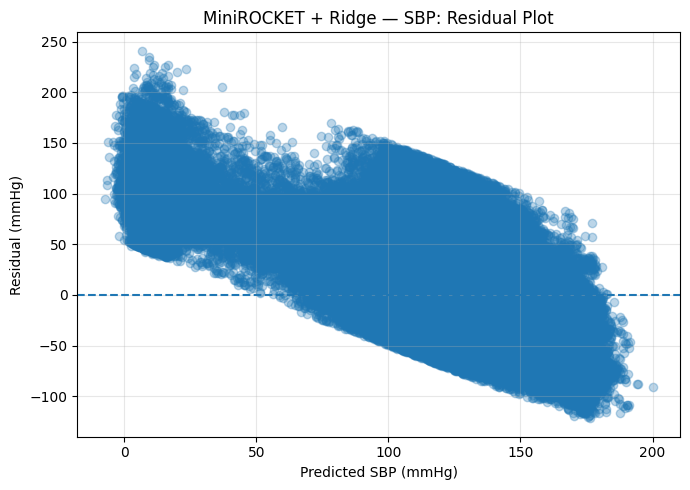

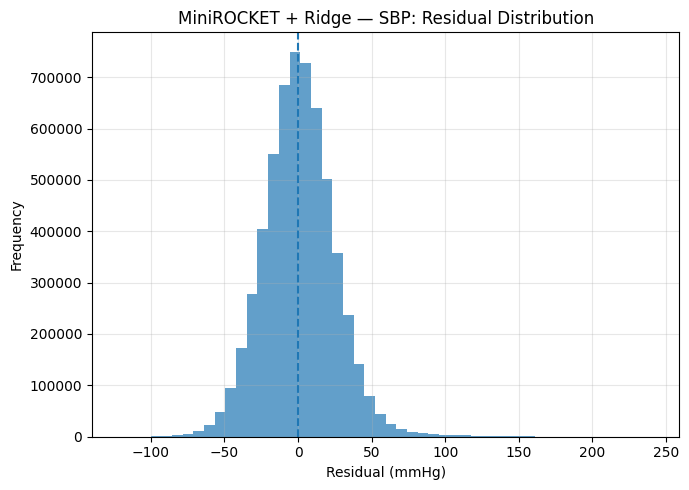

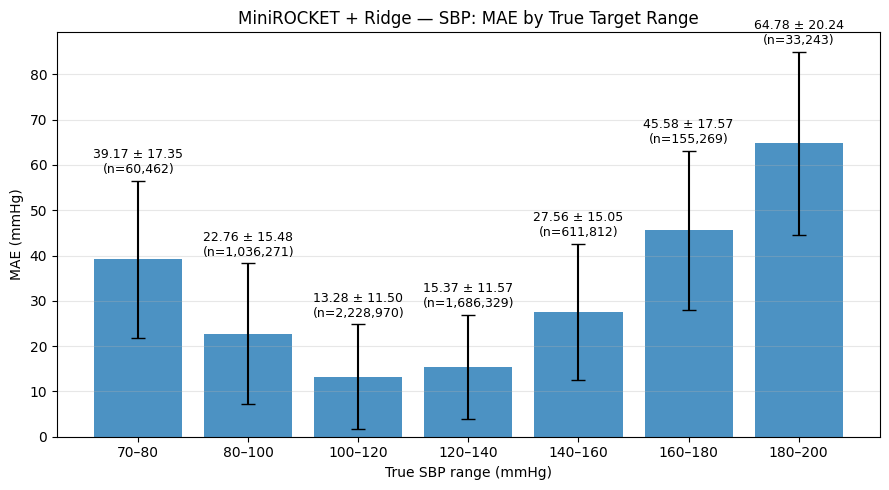

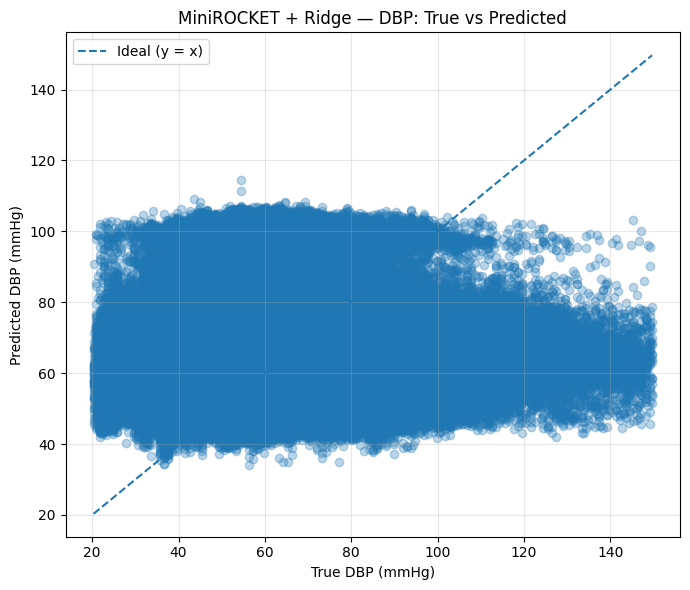

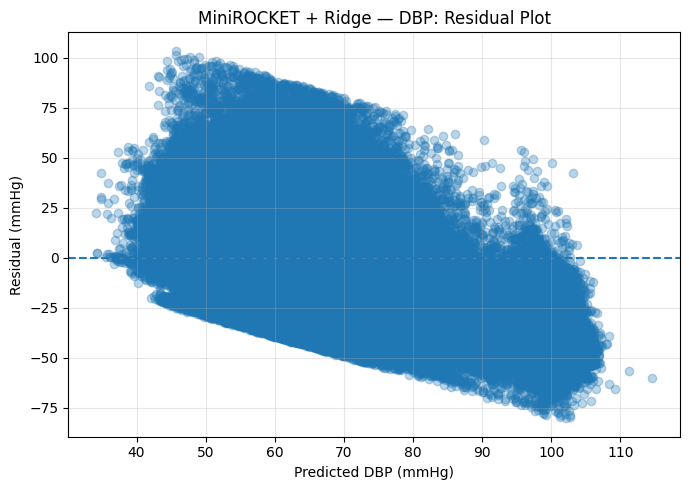

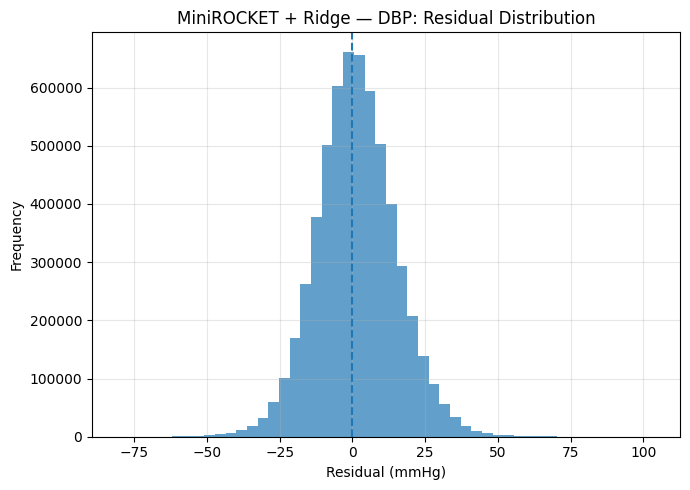

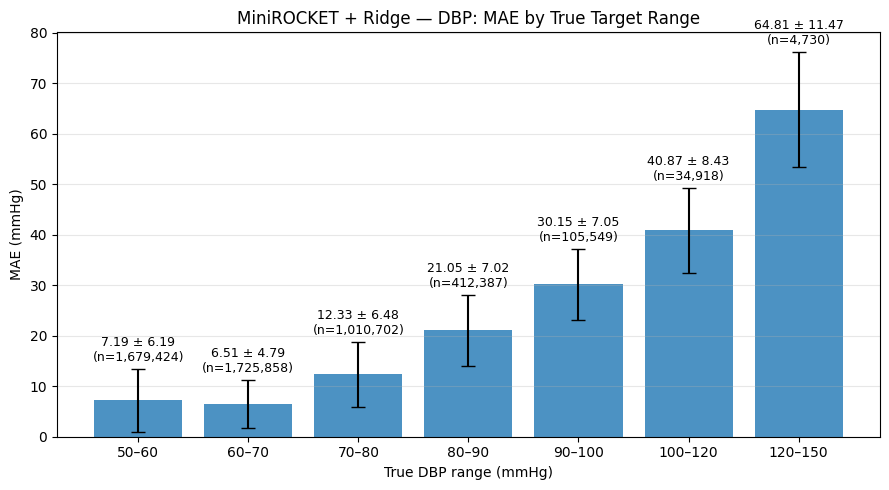


Final prediction shape:
(5837176, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  171.894928  126.510414  76.111603  57.965714
1  case_1  169.920013  123.217415  77.099091  56.850555
2  case_1  169.426300  127.909767  76.111603  59.217365
3  case_1  170.907501  133.706528  75.124176  61.863731
4  case_1  170.907501  125.899681  75.124176  57.402790


In [14]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR,
    rocket=rocket,
    best_en_sbp=grid_ridge_sbp,
    best_en_dbp=grid_ridge_dbp,
    model = "Ridge",
    batch_size=5000
)

## MLP ##

In [15]:
mlp_sbp, mlp_dbp = train_mlp(X_train_rocket, y_train, X_val_rocket, y_val)

epoch 00 | TRAIN loss 0.2251 MSE(SBP 244.54, DBP 67.69) RMSE(SBP 15.64, DBP 8.23) | VAL loss 0.2637 MSE(SBP 294.37, DBP 77.60) RMSE(SBP 17.16, DBP 8.81)


epoch 01 | TRAIN loss 0.1858 MSE(SBP 192.78, DBP 57.17) RMSE(SBP 13.88, DBP 7.56) | VAL loss 0.2392 MSE(SBP 258.13, DBP 71.21) RMSE(SBP 16.07, DBP 8.44)


epoch 02 | TRAIN loss 0.1675 MSE(SBP 170.85, DBP 52.02) RMSE(SBP 13.07, DBP 7.21) | VAL loss 0.2290 MSE(SBP 243.64, DBP 69.20) RMSE(SBP 15.61, DBP 8.32)


epoch 03 | TRAIN loss 0.1560 MSE(SBP 155.89, DBP 49.50) RMSE(SBP 12.49, DBP 7.04) | VAL loss 0.2249 MSE(SBP 238.35, DBP 68.46) RMSE(SBP 15.44, DBP 8.27)


epoch 04 | TRAIN loss 0.1443 MSE(SBP 142.01, DBP 45.81) RMSE(SBP 11.92, DBP 6.77) | VAL loss 0.2163 MSE(SBP 223.89, DBP 66.62) RMSE(SBP 14.96, DBP 8.16)


...

epoch 25 | TRAIN loss 0.0810 MSE(SBP 75.37, DBP 25.85) RMSE(SBP 8.68, DBP 5.08) | VAL loss 0.1948 MSE(SBP 197.66, DBP 61.06) RMSE(SBP 14.06, DBP 7.81)


epoch 26 | TRAIN loss 0.0803 MSE(SBP 75.21, DBP 25.56) RMSE(SBP 8.67, DBP 5.06) | VAL loss 0.1938 MSE(SBP 197.42, DBP 60.33) RMSE(SBP 14.05, DBP 7.77)


epoch 27 | TRAIN loss 0.0793 MSE(SBP 74.08, DBP 25.27) RMSE(SBP 8.61, DBP 5.03) | VAL loss 0.1947 MSE(SBP 196.87, DBP 61.17) RMSE(SBP 14.03, DBP 7.82)


epoch 28 | TRAIN loss 0.0789 MSE(SBP 73.41, DBP 25.15) RMSE(SBP 8.57, DBP 5.02) | VAL loss 0.1955 MSE(SBP 200.42, DBP 61.11) RMSE(SBP 14.16, DBP 7.82)


epoch 29 | TRAIN loss 0.0788 MSE(SBP 73.50, DBP 25.23) RMSE(SBP 8.57, DBP 5.02) | VAL loss 0.1919 MSE(SBP 195.97, DBP 60.14) RMSE(SBP 14.00, DBP 7.76)


In [16]:
y_pred_sbp = batch_predict(mlp_sbp, X_test_rocket)
y_pred_dbp = batch_predict(mlp_dbp, X_test_rocket)
print_metrics(y_test[:, 0], y_pred_sbp)
print_metrics(y_test[:, 1], y_pred_dbp)

RMSE: 15.1951
MSE : 230.8925
R²  : 0.5617
MAE : 10.5351
RMSE: 7.9631
MSE : 63.4109
R²  : 0.4910
MAE : 5.2828


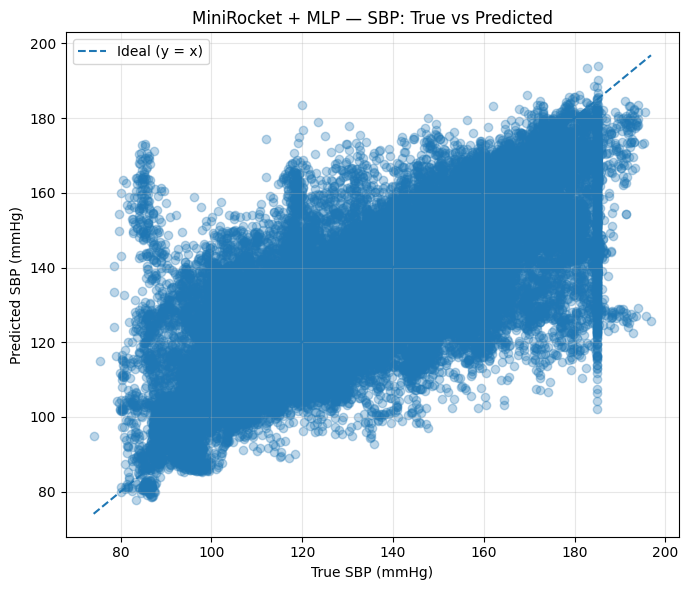

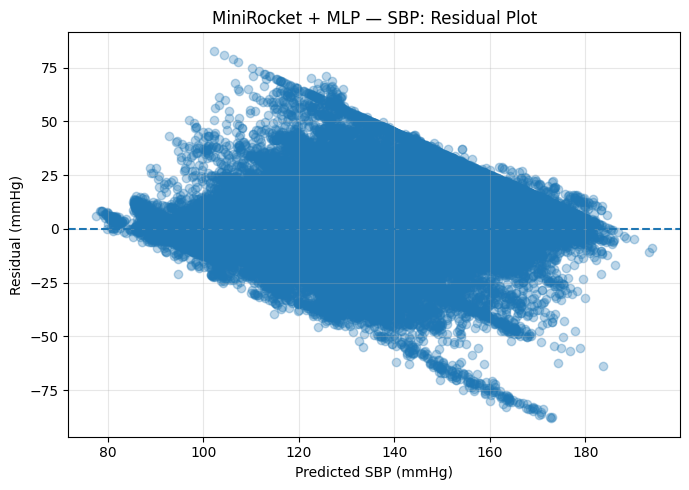

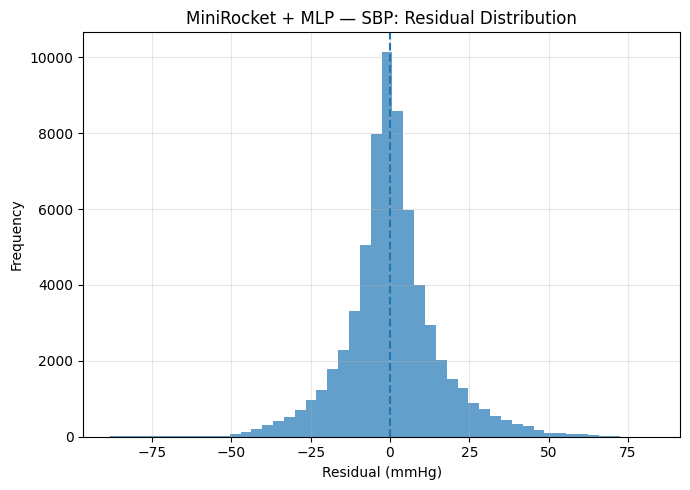

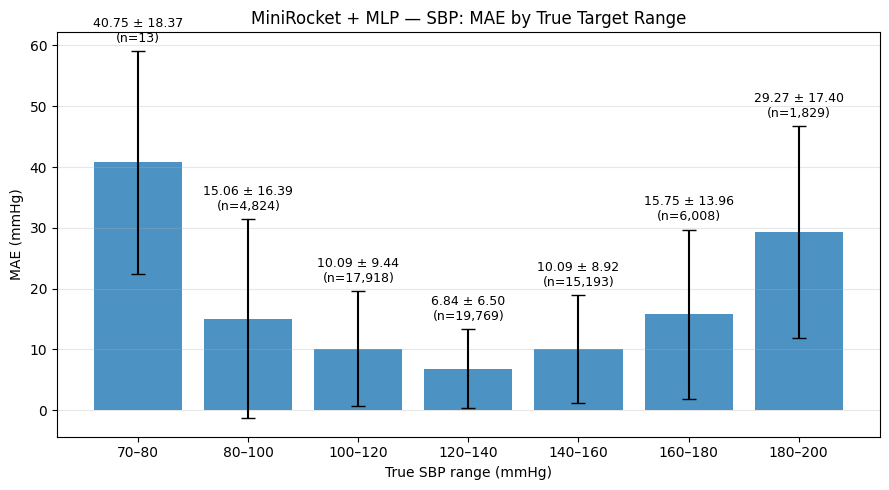

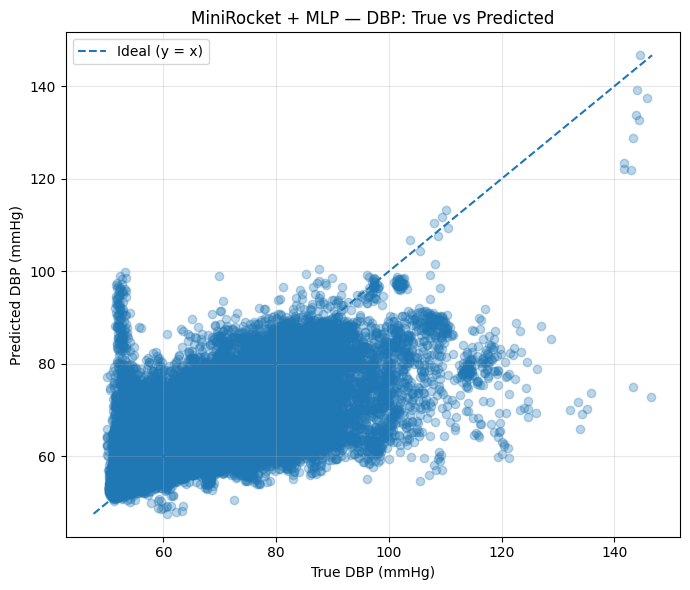

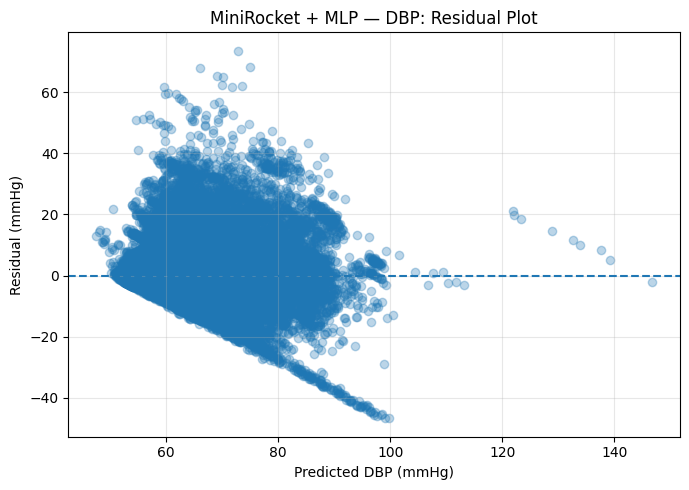

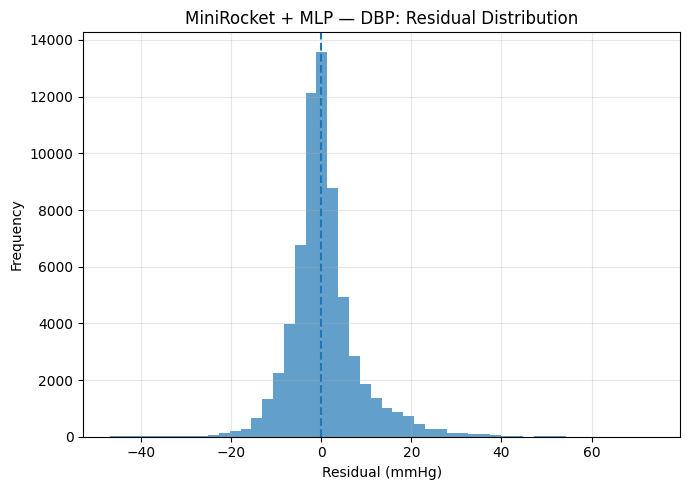

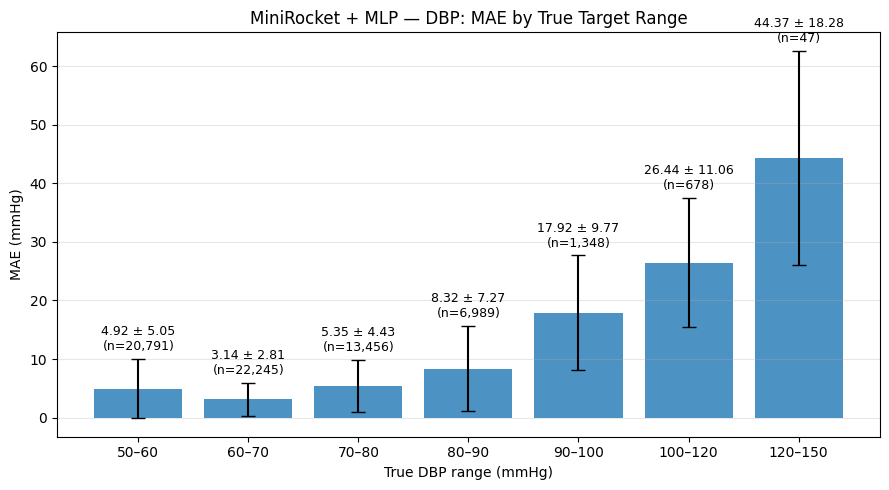

In [17]:
plot_regression_results(
    y_test_sbp,
    y_pred_sbp,
    "MiniRocket + MLP",
    "SBP"
)

plot_regression_results(
    y_test_dbp,
    y_pred_dbp,
    "MiniRocket + MLP",
    "DBP"
)

Number of VitalDB cases: 1962


MiniROCKET VitalDB prediction: 100%|██████████| 1962/1962 [1:03:48<00:00,  1.95s/case]




MiniROCKET + MLP
VITALDB ZERO-SHOT RESULTS

SBP
------------------------------
RMSE: 22.6310
MSE : 512.1632
R²  : -0.2007
MAE : 18.0901

DBP
------------------------------
RMSE: 12.8402
MSE : 164.8717
R²  : -0.0192
MAE : 10.1602


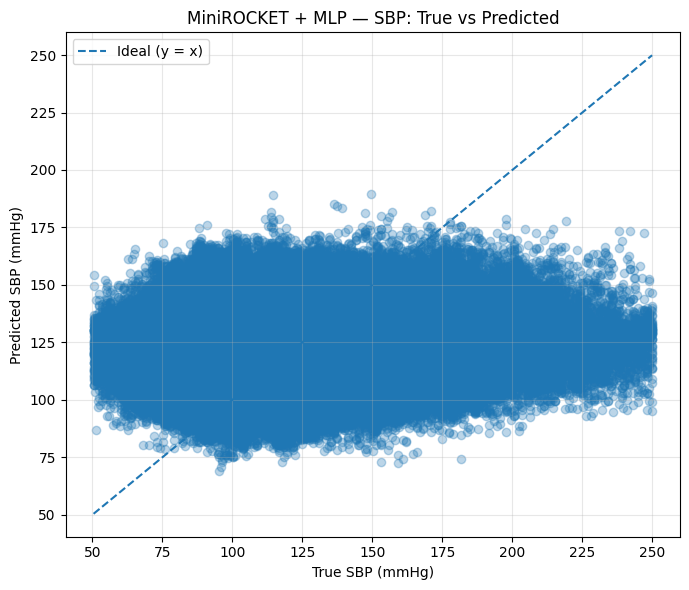

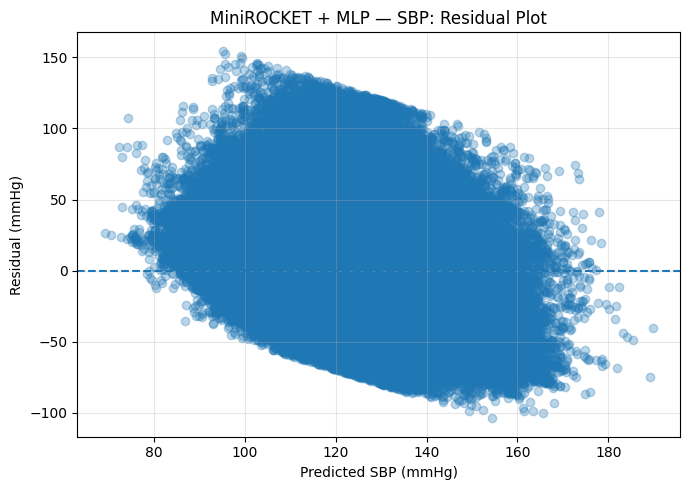

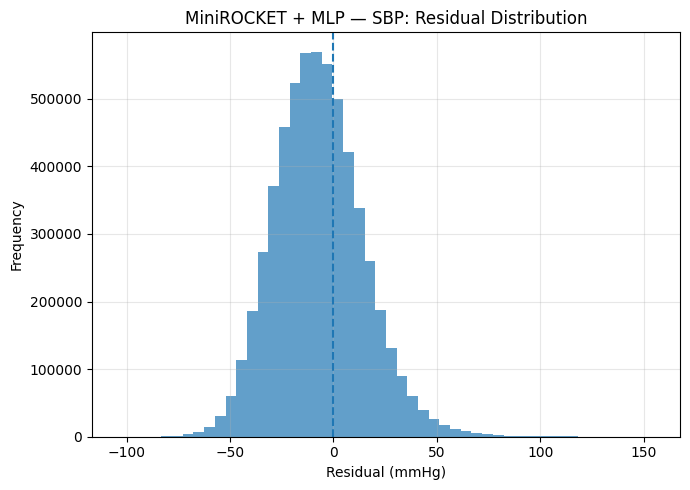

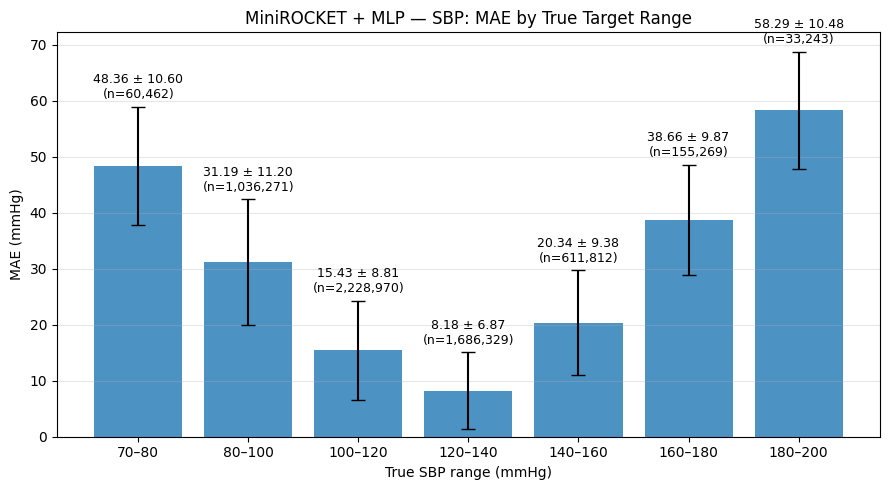

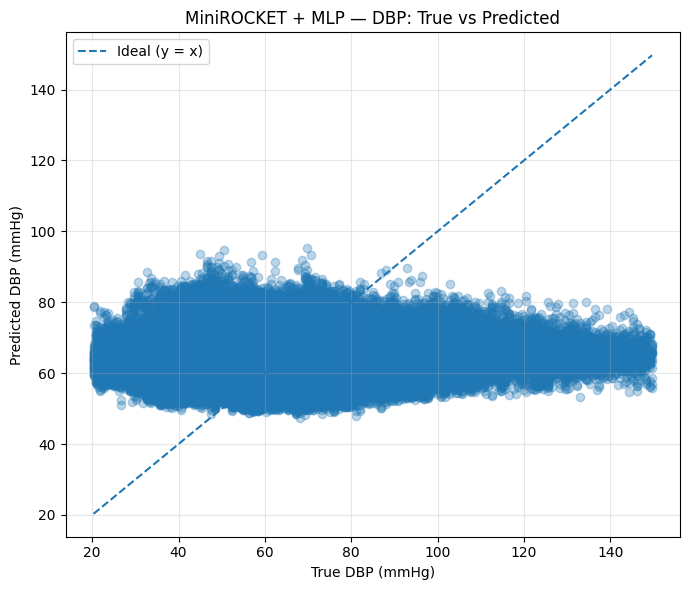

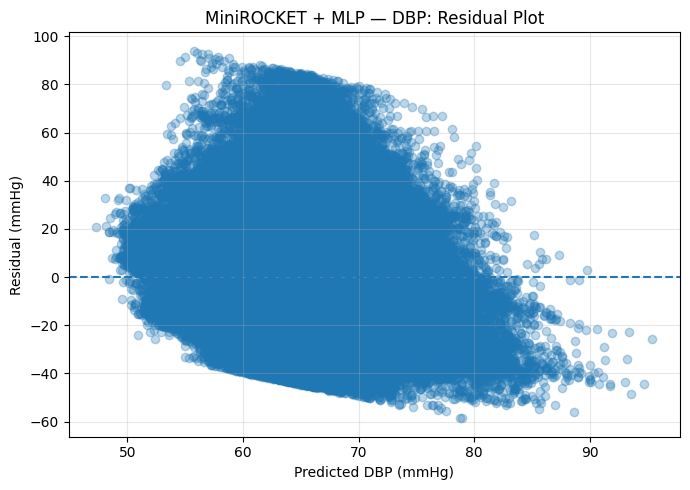

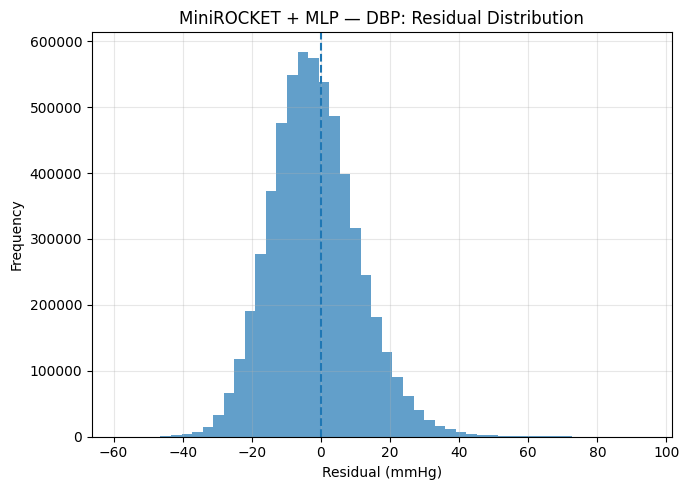

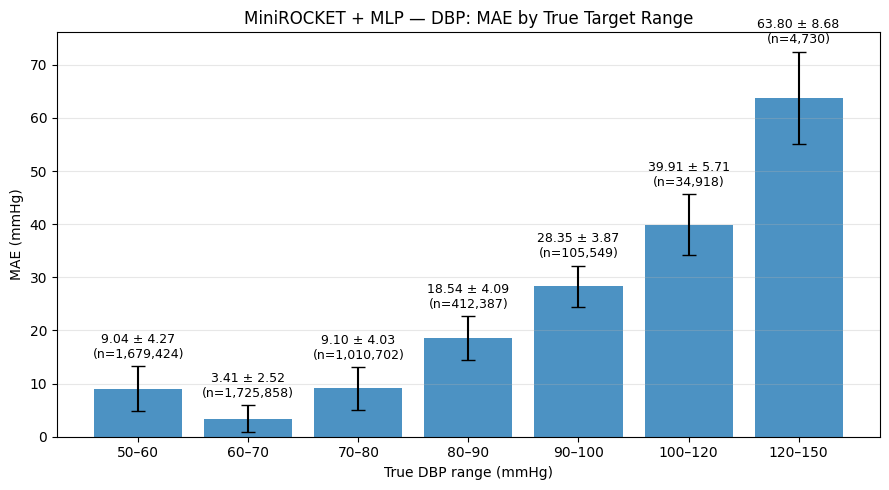


Final prediction shape:
(5837176, 5)

First 5 predictions:
  case_id    SBP_true    SBP_pred   DBP_true   DBP_pred
0  case_1  171.894928  123.669479  76.111603  63.995388
1  case_1  169.920013  127.418900  77.099091  64.644470
2  case_1  169.426300  122.124939  76.111603  63.792316
3  case_1  170.907501  116.878250  75.124176  63.371002
4  case_1  170.907501  116.040863  75.124176  63.268440


In [18]:
results_vitaldb = evaluate_minirocket_vitaldb(
    base_dir=BASE_DIR, rocket=rocket,
    best_en_sbp=mlp_sbp, best_en_dbp=mlp_dbp, model = "MLP", batch_size=2000)

## Feature Selection ##

In [19]:
sbp_idx, sbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 0],
    k=1000
)

dbp_idx, dbp_corr = select_top_pearson_features(
    X_train_rocket,
    y_train[:, 1],
    k=1000
)

In [20]:
print("SBP top features:", sbp_idx[:20])
print("SBP correlations:", sbp_corr[:20])

print("DBP top features:", dbp_idx[:20])
print("DBP correlations:", dbp_corr[:20])

SBP top features: [1554  972  438  233 1598 1795  272  962  430  556  519 1103  243 1082
  645  382  548  642  540  385]
SBP correlations: [-0.25935966  0.24454436  0.24439602 -0.23776448  0.23695844  0.23683211
 -0.23594245  0.23544356  0.23487885  0.23481894  0.23331717  0.23268566
 -0.2312861   0.23115793  0.2307822  -0.23062319  0.2305155   0.22969668
  0.22835378 -0.22808619]
DBP top features: [1935  239  526  383 1069  437  218 1420  649 2629  231 1170  552  521
  213  432 1391  234  210 2492]
DBP correlations: [ 0.22295886 -0.21910149  0.21854545 -0.21542098 -0.21496953  0.21418437
 -0.21124394 -0.20953357  0.20932677  0.20917313 -0.2091457   0.20758314
  0.20739911  0.20724204 -0.2069221   0.20280883 -0.20231019 -0.19997977
 -0.19852164 -0.19827466]
